# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import keras
from numba.core.utils import benchmark
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from keras_tuner import RandomSearch
from tensorflow.keras import  mixed_precision, layers
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from pathlib import Path
from datetime import datetime
from sklearn import metrics

# Weekly Test

## Data

In [2]:

daily_data = pd.DataFrame()
data_SP500 = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_SP500.parquet')
data_NDX = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_NASDAQ.parquet')
daily_data = pd.concat([data_SP500, data_NDX], ignore_index=True)
daily_data = daily_data.drop_duplicates(subset=['Ticker', 'Date'])
daily_data = daily_data.drop(columns='Adj Close')
daily_data


Price,Date,Close,High,Low,Open,Volume,Ticker
0,1976-07-01,0.385818,0.391612,0.385818,0.386977,344359.0,ETN
1,1976-07-01,0.109001,0.112029,0.109001,0.109001,2073600.0,MDT
2,1976-07-01,0.433622,0.441881,0.429492,0.433622,23970.0,DTE
3,1976-07-01,0.400973,0.406081,0.400973,0.400973,79200.0,EIX
4,1976-07-01,0.113854,0.117365,0.113854,0.117365,2615606.0,PFE
...,...,...,...,...,...,...,...
4276478,2025-11-21,170.500000,181.190002,166.309998,172.740005,29546700.0,MSTR
4276483,2025-11-21,113.239998,114.059998,111.290001,112.699997,9426700.0,PDD
4276488,2025-11-21,15.700000,15.960000,15.170000,15.550000,9337200.0,S
4276502,2025-11-21,33.990002,34.400002,32.205002,32.330002,2748700.0,GFS


In [3]:
class OHLCResampler:
    def __init__(self, data, date_col="Date", ticker_col="Ticker"):
        self.data = data.copy()
        self.date_col = date_col
        self.ticker_col = ticker_col

        # S'assurer que la colonne de date est bien en datetime
        self.data[date_col] = pd.to_datetime(self.data[date_col])
        self.data.set_index(date_col, inplace=True)

    def resample(self, period='W'):
        grouped = self.data.groupby(self.ticker_col)

        resampled = grouped.resample(period).agg({
            'Open': 'first',
            'High': 'max',
            'Low': 'min',
            'Close': 'last',
            'Volume': 'sum'
        }).reset_index()

        return resampled

In [4]:
# Exemple avec daily_data
resampler = OHLCResampler(daily_data)

# Period
df = resampler.resample('W')

## Target

In [5]:
def target_period(df, period, pourcentage_target):
    df = df.sort_values(by=['Ticker', 'Date'])
    # 1. Extraire le prix de fin de mois par Ticker
    target= df.groupby(['Ticker', pd.Grouper(key='Date', freq=period)])['Close'].last().reset_index()
    target['Target'] = target.groupby('Ticker')['Close'].pct_change()
    target = target.dropna()
    target['Target'] = (target['Target'] > pourcentage_target).astype(int)

    # 2. Joindre la target mensuelle aux données journalières
    target = target[['Ticker', 'Date', 'Target']]
    df = pd.merge_asof(
        df.sort_values(by='Date'),
        target.sort_values(by='Date'),
        on='Date',
        by='Ticker',
        direction='forward',
    )
    return df

In [6]:
data = target_period(df, period='3M', pourcentage_target=0.4)
data

/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_1174/1508566685.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  target= df.groupby(['Ticker', pd.Grouper(key='Date', freq=period)])['Close'].last().reset_index()
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_1174/1508566685.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  target['Target'] = target.groupby('Ticker')['Close'].pct_change()


,Ticker,Date,Open,High,Low,Close,Volume,Target
0,CLX,1976-07-04,0.457385,0.466719,0.448050,0.457385,389600.0,0.0
1,F,1976-07-04,0.238375,0.238884,0.232263,0.232263,5847678.0,0.0
2,AEP,1976-07-04,0.967605,0.973072,0.951205,0.962138,95100.0,0.0
3,MMM,1976-07-04,1.177587,1.193465,1.174941,1.190819,1305075.0,0.0
4,MCD,1976-07-04,0.609302,0.611906,0.598886,0.600189,4365900.0,0.0
...,...,...,...,...,...,...,...,...
803343,GNRC,2025-11-23,150.029999,155.000000,137.600006,146.039993,7003400.0,0.0
803344,WAB,2025-11-23,203.610001,204.179993,194.929993,200.220001,4682400.0,0.0
803345,GOOG,2025-11-23,286.399994,306.890015,279.010010,299.649994,185297600.0,0.0
803346,GFS,2025-11-23,32.880001,34.400002,32.020000,33.990002,12303700.0,0.0


In [7]:
data['Target'].value_counts()

Target
0.0    782065
1.0     21267
Name: count, dtype: int64

In [8]:
TICKER_TO_ID = {ticker: i + 1 for i, ticker in enumerate(data['Ticker'].unique())}
data['Ticker_ID'] = data['Ticker'].map(TICKER_TO_ID)
data

,Ticker,Date,Open,High,Low,Close,Volume,Target,Ticker_ID
0,CLX,1976-07-04,0.457385,0.466719,0.448050,0.457385,389600.0,0.0,1
1,F,1976-07-04,0.238375,0.238884,0.232263,0.232263,5847678.0,0.0,2
2,AEP,1976-07-04,0.967605,0.973072,0.951205,0.962138,95100.0,0.0,3
3,MMM,1976-07-04,1.177587,1.193465,1.174941,1.190819,1305075.0,0.0,4
4,MCD,1976-07-04,0.609302,0.611906,0.598886,0.600189,4365900.0,0.0,5
...,...,...,...,...,...,...,...,...,...
803343,GNRC,2025-11-23,150.029999,155.000000,137.600006,146.039993,7003400.0,0.0,390
803344,WAB,2025-11-23,203.610001,204.179993,194.929993,200.220001,4682400.0,0.0,259
803345,GOOG,2025-11-23,286.399994,306.890015,279.010010,299.649994,185297600.0,0.0,346
803346,GFS,2025-11-23,32.880001,34.400002,32.020000,33.990002,12303700.0,0.0,503


## Features

In [9]:
import numpy as np
import pandas as pd
from collections import Counter

class Configuration_Features:

    def __init__(self, df):
        self.df = df.dropna().copy()

    def _rename_columns(self, rename_map):
        # Prevent duplicate names by suffixing
        counts = Counter(rename_map.values())
        used = {}
        for old_name, new_name in rename_map.items():
            if counts[new_name] > 1:
                used.setdefault(new_name, 0)
                used[new_name] += 1
                rename_map[old_name] = f"{new_name}_{used[new_name]}"
        self.df.rename(columns=rename_map, inplace=True)

    def return_(self):
        self.df['Return'] = self.df.groupby('Ticker')['Close'].pct_change()

    def moving_average(self, window):
        for w in window:
            self.df[f'ma_{w}'] = self.df.groupby('Ticker')['Close']\
                .rolling(window=w, min_periods=1).mean().reset_index(level=0, drop=True)
        self.df['ma_12'] = self.df.groupby('Ticker')['Close'].rolling(window=12, min_periods=1).mean().reset_index(level=0, drop=True)
        self.df['ma_12_Volume'] = self.df.groupby('Ticker')['Volume'].rolling(window=12, min_periods=1).mean().reset_index(level=0, drop=True)

    def distance_moving_average(self, window):
        window1 = window.copy()
        for w in window:
            for w1 in window1:
                if w != w1 and w < w1:
                    self.df[f'distance_ma_{w}/{w1}'] = abs(self.df[f'ma_{w}'] - self.df[f'ma_{w1}'])

    def performance(self, window):
        rename_map = {}
        for w in window:
            col_name = f'performance_{w}'
            self.df[col_name] = self.df.groupby('Ticker')['ma_12'].pct_change(periods=w)
            if w == 4:
                new_name = 'performance_short'
            elif w == 12:
                new_name = 'performance_medium_short'
            elif w == 25:
                new_name = 'performance_medium_long'
            else:
                new_name = 'performance_long'
            rename_map[col_name] = new_name

        # Rename avoiding duplicates
        self._rename_columns(rename_map)

        self.df['Year'] = pd.to_datetime(self.df['Date']).dt.year
        anchor_close = self.df.groupby(['Ticker', 'Year'])['ma_12'].transform('first')
        self.df['performance_ytd'] = self.df['Close'] / anchor_close - 1
        self.df.drop(columns='Year', inplace=True)

    def volume(self, window):
        rename_map = {}
        for w in window:
            col_name = f'volume_{w}'
            self.df[col_name] = self.df.groupby('Ticker')['ma_12_Volume']\
                .pct_change(periods=w)

            if w == 4:
                new_name = 'volume_short'
            elif w == 12:
                new_name = 'volume_medium_short'
            elif w == 25:
                new_name = 'volume_medium_long'
            else:
                new_name = 'volume_long'
            rename_map[col_name] = new_name

        self._rename_columns(rename_map)

    def RSI(self, window):
        for w in window:
            self.df['delta'] = self.df.groupby('Ticker')['Close'].diff()
            self.df['gain'] = self.df['delta'].where(self.df['delta'] > 0, 0.0)
            self.df['loss'] = -self.df['delta'].where(self.df['delta'] < 0, 0.0)

            self.df['avg_gain'] = self.df.groupby('Ticker')['gain'].rolling(window=w, min_periods=1).mean().reset_index(level=0, drop=True)
            self.df['avg_loss'] = self.df.groupby('Ticker')['loss'].rolling(window=w, min_periods=1).mean().reset_index(level=0, drop=True)

            self.df['rs'] = self.df['avg_gain'] / self.df['avg_loss']
            self.df[f'RSI_{w}'] = 100 - (100 / (1 + self.df['rs']))
            self.df[f'MA_RSI_{w}'] = self.df.groupby('Ticker')[f'RSI_{w}'].rolling(window=100, min_periods=1).mean().reset_index(level=0, drop=True)
            self.df = self.df.drop(columns=f'RSI_{w}')

        self.df.drop(columns=['delta', 'gain', 'loss', 'avg_gain', 'avg_loss', 'rs'], inplace=True)


    def date_numeric(self):
        self.df['Day_num'] = self.df['Date'].dt.dayofweek
        self.df['Month_num'] = self.df['Date'].dt.month
        self.df['Year_num'] = self.df['Date'].dt.year


    def cleaning(self):
        self.df = self.df.replace([np.inf, -np.inf], np.nan)
        self.df = self.df.drop(columns=['ma_12', 'ma_12_Volume'])
        self.df = self.df.dropna()

    def get_dataframe(self):
        return self.df


In [10]:

liste_ma = [50, 100]
liste_days = [4, 12, 25, 50]
liste_rsi = [25]

"""
liste_ma = [50, 25]
liste_days = [3, 6, 12, 60]
liste_rsi = [25]
"""

features = Configuration_Features(data)
features.return_()
features.moving_average(window=liste_ma)
features.distance_moving_average(window=liste_ma)
features.performance(window=liste_days)
features.volume(window=liste_days)
features.RSI(window=liste_rsi)
features.date_numeric()
features.cleaning()
data_features = features.get_dataframe()
print("Data Features Shape:", data_features.shape)


Data Features Shape: (777050, 26)


In [11]:
display(data_features.tail())

,Ticker,Date,Open,High,Low,Close,Volume,Target,Ticker_ID,Return,...,performance_long,performance_ytd,volume_short,volume_medium_short,volume_medium_long,volume_long,MA_RSI_25,Day_num,Month_num,Year_num
803343,GNRC,2025-11-23,150.029999,155.000000,137.600006,146.039993,7003400.0,0.0,390,-0.034191,...,-0.001768,-0.151884,0.250396,0.138261,0.417654,0.364907,53.785729,6,11,2025
803344,WAB,2025-11-23,203.610001,204.179993,194.929993,200.220001,4682400.0,0.0,259,-0.018144,...,0.032509,0.029765,-0.025854,-0.065548,0.014641,0.031499,61.980346,6,11,2025
803345,GOOG,2025-11-23,286.399994,306.890015,279.010010,299.649994,185297600.0,0.0,346,0.081847,...,0.537486,0.684191,0.118560,-0.026436,-0.099033,0.353144,57.948561,6,11,2025
803346,GFS,2025-11-23,32.880001,34.400002,32.020000,33.990002,12303700.0,0.0,503,0.028442,...,-0.173239,-0.194900,0.039658,0.598074,0.593184,0.904140,44.430050,6,11,2025
803347,ZTS,2025-11-23,120.709999,122.360001,115.250000,122.059998,27206900.0,0.0,422,0.010263,...,-0.231158,-0.297677,0.219858,0.156105,0.256129,0.577205,46.745611,6,11,2025


## Train / Test

In [12]:
n_label = len(data_features['Target'].unique())
total_label = len(data_features['Target'])
class_weight = {}

for i in data_features['Target'].unique():
    n = len(data_features[data_features['Target'] == i])
    w = total_label/(n_label*n)
    class_weight[i] = w


class_weight

{0.0: 0.5127242446876741, 1.0: 20.147531632441403}

In [13]:
from sklearn.preprocessing import StandardScaler

class Train_Test:
  def __init__(self, df):
    self.df = df.copy()

  def Split(self, cut_train_end, cut_val_end):
    mask_train = self.df['Date'] < cut_train_end
    mask_val   = (self.df['Date'] >= cut_train_end) & (self.df['Date'] < cut_val_end)
    mask_test  = self.df['Date'] >= cut_val_end
    return mask_train, mask_val, mask_test

  def train_val_test(self, features, Target, mask_train, mask_val, mask_test):
    X_df = self.df[features]
    y_sr = self.df[Target]
    X_train_df, y_train = X_df.loc[mask_train], y_sr.loc[mask_train]
    X_val_df,   y_val   = X_df.loc[mask_val],   y_sr.loc[mask_val]
    X_test_df,  y_test  = X_df.loc[mask_test],  y_sr.loc[mask_test]

    print("Tailles (lignes) ->",
      "train:", len(X_train_df), round(len(X_train_df)/len(self.df), 2),
      "val:", len(X_val_df), round(len(X_val_df)/len(self.df), 2),
      "test:", len(X_test_df), round(len(X_test_df)/len(self.df), 2),
      "total:", len(X_train_df)+len(X_val_df)+len(X_test_df),
      "data:", len(self.df))

    return X_train_df, y_train, X_val_df, y_val, X_test_df, y_test

  def Scale(X_train_df, X_val_df,X_test_df):
    scaler = StandardScaler()
    X_train_scale = scaler.fit_transform(X_train_df)
    X_val_scale   = scaler.transform(X_val_df)
    X_test_scale  = scaler.transform(X_test_df)
    return X_train_scale, X_val_scale, X_test_scale

  def Shape_X_Train_Val_Test(X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test):
    print(f"Entraînement : {X_train_scale.shape}, {y_train.shape}")
    print(f"Validation : {X_val_scale.shape}, {y_val.shape}")
    print(f"Test : {X_test_scale.shape}, {y_test.shape}")

  def get_Train_Val_Test(X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test):
    return X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test

In [14]:
cut_train_end = '2018-01-01'
cut_val_end = '2020-01-01'
X_features = data_features.drop(columns=['Target', 'Ticker', 'Date', 'Low', 'High', 'Open', 'Close', 'ma_50', 'ma_100'])
y_features = data_features['Target']
Y_features = data_features['Target']

tt = Train_Test(data_features)
mask_train, mask_val, mask_test = tt.Split(cut_train_end, cut_val_end)
X_train_df, y_train, X_val_df, y_val, X_test_df, y_test = tt.train_val_test(X_features.columns, Y_features.name, mask_train, mask_val, mask_test)
X_train_scale, X_val_scale, X_test_scale = Train_Test.Scale(X_train_df, X_val_df, X_test_df)
Train_Test.Shape_X_Train_Val_Test(X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test)
X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test = Train_Test.get_Train_Val_Test(X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test)


Tailles (lignes) -> train: 574153 0.74 val: 48902 0.06 test: 153995 0.2 total: 777050 data: 777050
Entraînement : (574153, 17), (574153,)
Validation : (48902, 17), (48902,)
Test : (153995, 17), (153995,)


## Features Reduction

### PCA

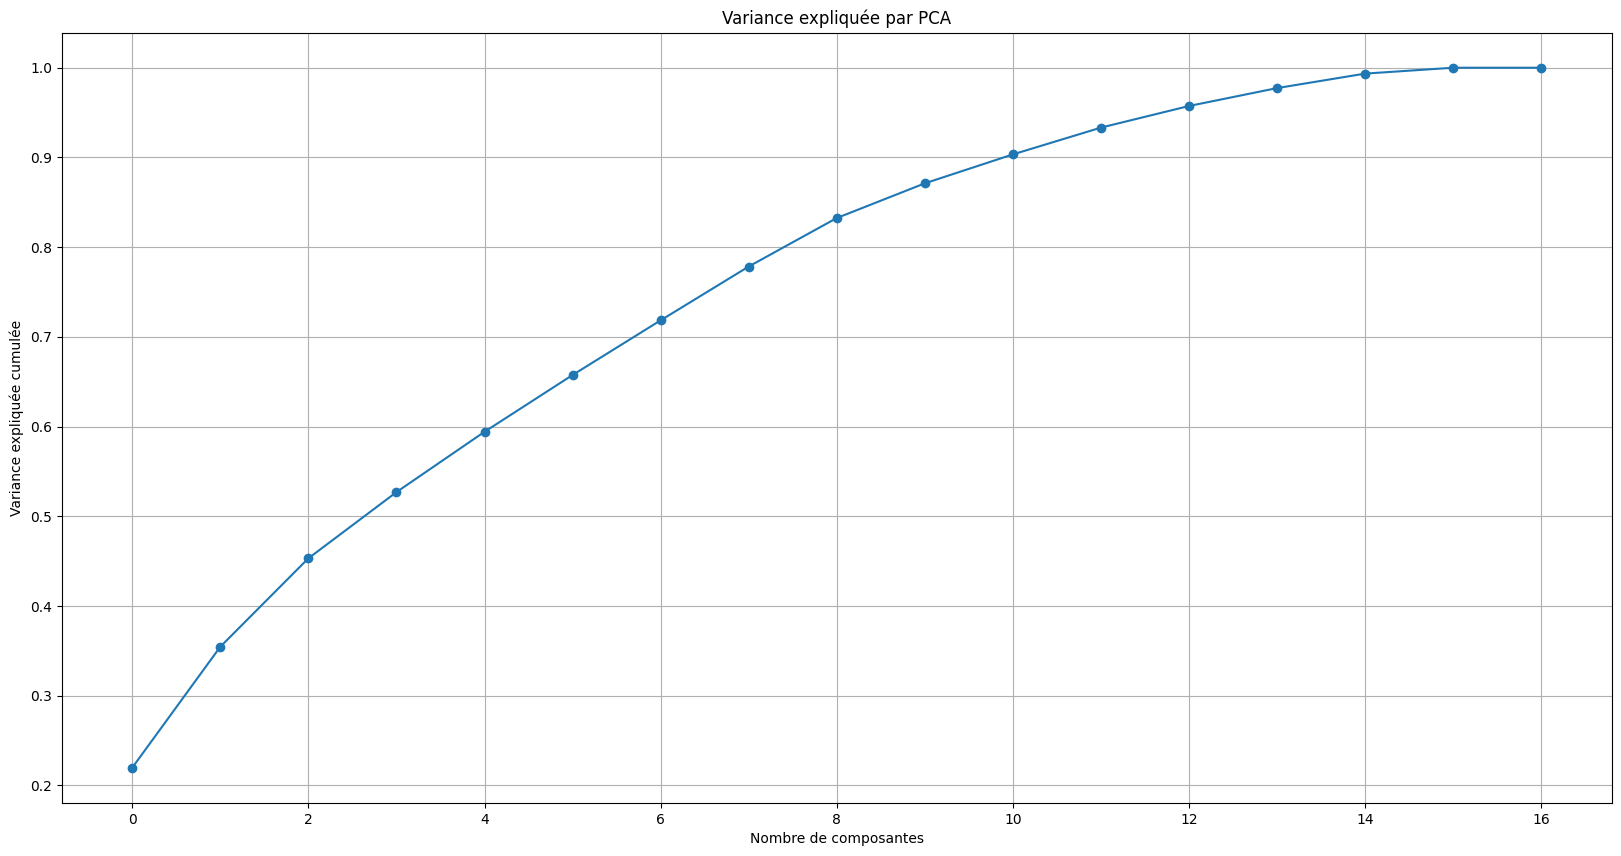

In [15]:
pca = PCA()
pca.fit(X_train_scale)  # X doit être centré-réduit !

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(20, 10))
plt.plot(cumulative_var, marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée par PCA")
plt.grid()
plt.show()

### Correlation Matrix

In [16]:
threshold = 0.8
col_corr = set()  # Ensemble des colonnes à supprimer
corr_matrix = X_train_df.corr()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            col_corr.add(colname)

print(f"Features à supprimer (corrélation > {threshold}) :")
print(col_corr)

# Supprimer les colonnes redondantes
df_reduced = X_train_df.drop(columns=col_corr)

Features à supprimer (corrélation > 0.8) :
set()


## Model

In [17]:
file_path = "/Users/forget/PycharmProjects/PythonProject/PythonProject/DeepLearning_Trading/bot/model/Classification/Weekly_6months.h5"

early_stop = EarlyStopping(monitor='loss', mode='min', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(file_path, monitor='loss', mode='min', save_best_only=True)

MyPath = Path("../logs/fit") / datetime.now().strftime("%Y%m%d-%H%M%S")

# Dossier de logs unique par session
log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=str(MyPath),
    histogram_freq=1,  # Log des histogrammes des poids
    write_graph=True,  # Visualisation du graphe du modèle
    write_images=True  # Affiche images d’entrée/sortie si applicable
)
callbacks = [early_stop, checkpoint, tensorboard_callback]
print("Chemin complet :", f"tensorboard --logdir={MyPath.resolve()}")

Chemin complet : tensorboard --logdir=/Users/forget/PycharmProjects/PythonProject/PythonProject/DeepLearning_Trading/bot/logs/fit/20251207-222057


In [18]:
def build_model(hp):
    n_hidden = hp.Int('n_hidden', min_value=1, max_value=15, step=1)
    n_neurons = hp.Int('n_neurons', min_value=16, max_value=512, step=8)
    learning_rate = hp.Float('learning_rate', min_value=1e-3, max_value=1e-1, sampling='log')

    optimizer_choice = hp.Choice('optimizer', values=['adam', 'sgd'])
    if optimizer_choice == "adam":
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate, beta_1=0.9, beta_2=0.999,
            epsilon=1e-08, decay=0.0
        )
    else:
        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate, momentum=0.9, nesterov=True
        )

    model = keras.Sequential()
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['recall', 'precision'])

    return model

In [19]:
random_search_tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    directory="Classification_Stock_Market_US_Model/Classification/",
    project_name="Weekly_6months",
    seed=42
)

Reloading Tuner from Classification_Stock_Market_US_Model/Classification/Weekly_6months/tuner0.json


In [20]:
random_search_tuner.search(X_train_scale, y_train, epochs=500, callbacks=callbacks, validation_data=(X_val_scale, y_val), batch_size=32768, class_weight=class_weight)

Trial 6 Complete [00h 01m 27s]
val_loss: 87.19913482666016

Best val_loss So Far: 0.47661536931991577
Total elapsed time: 5d 08h 55m 47s


### Prédiction

In [21]:
best_model = random_search_tuner.get_best_models(num_models=1)[0]
best_hps = random_search_tuner.get_best_hyperparameters(num_trials=1)[0]
y_proba = best_model.predict(X_test_scale)

print("Meilleurs hyperparamètres :")
print(best_hps.values)
print(f'Prédiction of test: {y_proba}')

/Users/forget/PycharmProjects/PythonProject/PythonProject/DeepLearning_Trading/.venv2/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/Users/forget/PycharmProjects/PythonProject/PythonProject/DeepLearning_Trading/.venv2/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 86 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


4813/4813 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
Meilleurs hyperparamètres :
{'n_hidden': 10, 'n_neurons': 32, 'learning_rate': 0.006562536901904111, 'optimizer': 'adam'}
Prédiction of test: [[1.6513943e-10]
 [6.2984157e-14]
 [3.0244914e-11]
 ...
 [9.9974829e-01]
 [4.2930026e-13]
 [2.0523649e-14]]


## Evaluation

In [22]:
y_pred = (y_proba > 0.5).astype(int)

### Classification Report

In [23]:
# Rapport de classification
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96    149831
         1.0       0.13      0.26      0.17      4164

    accuracy                           0.93    153995
   macro avg       0.55      0.61      0.57    153995
weighted avg       0.96      0.93      0.94    153995



### Matrice de confusion

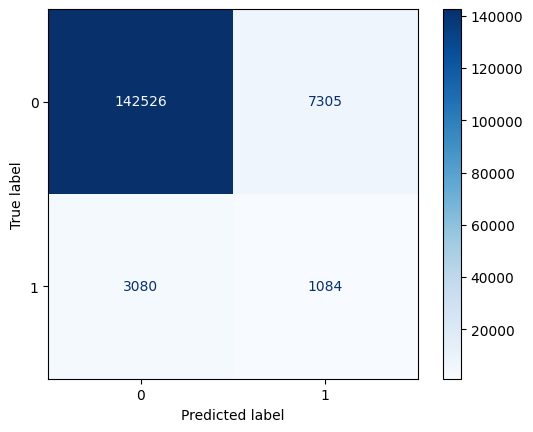

In [24]:
import sklearn.metrics as skm

cm = skm.confusion_matrix(y_test, y_pred)
disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")


## Backtest

In [47]:
class Backtester:
    def __init__(self, data, start_date, initial_capital=1000, save_month=0, fee_per_trade=0, leverage=1.0, top=None):
        self.data = data.copy()
        self.initial_capital = initial_capital
        self.save_month = save_month
        self.fee_per_trade = fee_per_trade
        self.leverage = leverage
        self.top = top
        self.start_date = start_date

        self.Prediction()
        self._prepare_data()
        self._reset_state()


    def Prediction(self):
        self.data = self.data[self.data['Date'] >= self.start_date]
        test = self.data.drop(columns=['Ticker', 'Date', 'Low', 'High', 'Open', 'Close', 'ma_50', 'ma_100'])
        scaler = StandardScaler()
        test_scale = scaler.fit_transform(test)
        self.data['Proba'] = best_model.predict(test_scale)

    def _prepare_data(self):
        self.df = self.data[["Date", "Ticker", "Close", "Proba", "Return", "ma_50", "ma_100"]] \
            .sort_values(["Date", "Ticker"]) \
            .copy()

        self.df['Date'] = pd.to_datetime(self.df['Date'])

        if self.top is not None:

            self.df['Prediction'] = (self.df['Proba'] > self.top).astype(int)

        self.df["BuySignal"] = (self.df["Prediction"] == 1)
        self.df["SellSignal"] = self.df["ma_50"] > self.df['Close']
        self.df["NextReturn"] = self.df.groupby("Ticker")["Return"].shift(-1)
        self.unique_dates = self.df["Date"].drop_duplicates().sort_values().to_numpy()

    def _reset_state(self):
        self.capital = self.initial_capital
        self.prev_holdings = set()

        self.portfolio_values = []
        self.returns = []
        self.position_count = []
        self.fee_history = []
        self.ticker_history = {}
        self.mean_return_history = []

    def _process_day(self, day, date):
        # Ajout du capital mensuel (épargne)
        self.capital += self.save_month

        buy_set = set(day.loc[day["BuySignal"], "Ticker"])

        current_portfolio = buy_set

        # Frais
        opened = current_portfolio - self.prev_holdings
        closed = self.prev_holdings - current_portfolio
        trades = len(opened) + len(closed)
        fees = trades * self.fee_per_trade
        self.capital = max(0, self.capital - fees)

        # Calcul rendement t+1
        r = day.loc[day["Ticker"].isin(current_portfolio), "NextReturn"].dropna().to_numpy()
        l = day.loc[day["Ticker"].isin(current_portfolio), ["Ticker", "NextReturn", "Proba"]]

        # Construction du dictionnaire : { 'Ticker': {'Return': ..., 'Prediction': ...} }
        tickers_info = {
            row['Ticker']: {
                'Return': row['NextReturn'],
                'Prediction': row['Proba']
            }
            for _, row in l.iterrows()
        }

        self.ticker_history[date] = tickers_info

        mean_return = np.mean(r) * self.leverage if len(r) > 0 else 0
        self.capital *= (1 + mean_return)

        # Historique
        self.portfolio_values.append(self.capital)
        self.returns.append(mean_return)
        self.position_count.append(len(current_portfolio))
        self.fee_history.append(fees)
        self.ticker_history[date] = l
        self.mean_return_history.append(mean_return)

        self.prev_holdings = current_portfolio

    def run(self):
        self._reset_state()

        for date in self.unique_dates:
            day = self.df.loc[self.df["Date"] == date]
            self._process_day(day, date)

        # Résultats journaliers
        self.performance = pd.DataFrame({
            "Date": self.unique_dates,
            "Capital": self.portfolio_values,
            "Return": np.array(self.returns),
            "Ticker_Count": self.position_count,
            "Fees": self.fee_history,
            "Return_Mean": self.mean_return_history,
        }).set_index("Date")

        return self.performance

    def summary(self):
        final_capital = self.portfolio_values[-1]
        total_return = (final_capital / self.initial_capital) - 1
        avg_positions = np.mean(self.position_count)

        # --- Durée totale ---
        start = pd.to_datetime(self.performance.index[0])
        end = pd.to_datetime(self.performance.index[-1])
        n_years = (end - start).days / 365

        # --- CAGR ---
        cagr = (final_capital / self.initial_capital) ** (1 / n_years) - 1

        # --- Sharpe Ratio (hebdomadaire) ---
        risk_free_annual = 0.03
        risk_free_weekly = (1 + risk_free_annual) ** (1 / 52) - 1

        weekly_returns = np.array(self.returns)
        excess_returns = weekly_returns - risk_free_weekly

        sharpe_ratio = (
            np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(52)
            if np.std(excess_returns) > 0 else np.nan
        )

        # --- Max Drawdown ---
        capital_series = pd.Series(self.portfolio_values, index=self.performance.index)
        running_max = capital_series.cummax()
        drawdowns = (capital_series / running_max) - 1
        max_drawdown = drawdowns.min()  # Négatif, ex: -0.25 => -25%

        return {
            "Initial Capital": round(self.initial_capital, 2),
            "Final Capital": round(final_capital, 2),
            "Total Return %": round(total_return * 100, 2),
            "CAGR %": round(cagr * 100, 2),
            "Sharpe Ratio": round(sharpe_ratio, 2),
            "Max Drawdown %": round(max_drawdown * 100, 2),
            "Avg Positions Held": round(avg_positions, 2),
            "Total Fees Paid": round(sum(self.fee_history), 2),
            "Period (years)": round(n_years, 2)
        }

In [37]:
class BacktestExporter:
    def __init__(self, ticker_history):
        """
        :param ticker_history: dictionnaire de la forme
               {date: {ticker: {'Return': x, 'Prediction': y}, ...}, ...}
        """
        self.ticker_history = ticker_history
        self.df = self._convert_to_dataframe()

    def _convert_to_dataframe(self):
        records = []
        for date, tickers in self.ticker_history.items():
            for ticker, info in tickers.items():
                records.append({
                    "Date": pd.to_datetime(date),
                    "Ticker": ticker,
                    "Return": info.get("Return", None),
                    "Prediction": info.get("Proba", None)
                })
        return pd.DataFrame(records)

    def to_dataframe(self):
        return self.df.copy()

    def to_csv(self, path="ticker_history.csv"):
        self.df.to_csv(path, index=False)
        print(f"✅ Exported to CSV: {path}")

    def to_excel(self, path="ticker_history.xlsx"):
        self.df.to_excel(path, index=False)
        print(f"✅ Exported to Excel: {path}")

    def to_json(self, path="ticker_history.json"):
        self.df.to_json(path, orient="records", date_format="iso")
        print(f"✅ Exported to JSON: {path}")

In [38]:
daily_data_test = pd.DataFrame()
data_SP500 = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_SP500.parquet')
#ata_NDX = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_NASDAQ.parquet')
#data_MidCap = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_MidCap_US.parquet')
#data_SmallCap = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_SmallCap_US.parquet')
data_MP = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_MP.parquet')
#daily_data_test = pd.concat([data_SP500, data_NDX, data_MidCap, data_SmallCap, data_MP], ignore_index=True)
daily_data_test = pd.concat([data_SP500, data_MP], ignore_index=True)
daily_data_test = daily_data_test.drop_duplicates(subset=['Ticker', 'Date'])
daily_data_test = daily_data_test.drop(columns='Adj Close')
daily_data_test

Price,Date,Close,High,Low,Open,Volume,Ticker
0,1976-07-01,0.385818,0.391612,0.385818,0.386977,344359.0,ETN
1,1976-07-01,0.109001,0.112029,0.109001,0.109001,2073600.0,MDT
2,1976-07-01,0.433622,0.441881,0.429492,0.433622,23970.0,DTE
3,1976-07-01,0.400973,0.406081,0.400973,0.400973,79200.0,EIX
4,1976-07-01,0.113854,0.117365,0.113854,0.117365,2615606.0,PFE
...,...,...,...,...,...,...,...
3881998,2025-11-28,558.599976,558.599976,556.150024,557.000000,64.0,GD=F
3881999,2025-12-01,558.349976,558.950012,557.099976,557.099976,55.0,GD=F
3882000,2025-12-02,554.700012,554.700012,554.700012,554.700012,1.0,GD=F
3882001,2025-12-03,556.700012,556.700012,556.700012,556.700012,0.0,GD=F


In [39]:
# Exemple avec daily_data
resampler = OHLCResampler(daily_data_test)
# Period
df = resampler.resample('W')

TICKER_TO_ID = {ticker: i + 1 for i, ticker in enumerate(df['Ticker'].unique())}
df['Ticker_ID'] = df['Ticker'].map(TICKER_TO_ID)

liste_ma = [50, 100]
liste_days = [4, 12, 25, 50]
liste_rsi = [25]

"""
liste_ma = [50, 25]
liste_days = [3, 6, 12, 60]
liste_rsi = [25]
"""

features = Configuration_Features(df)
features.return_()
features.moving_average(window=liste_ma)
features.distance_moving_average(window=liste_ma)
features.performance(window=liste_days)
features.volume(window=liste_days)
features.RSI(window=liste_rsi)
features.date_numeric()
features.cleaning()
df_features = features.get_dataframe()
print("Data Features Shape:", df_features.shape)

Data Features Shape: (778182, 25)


## Metrics

In [40]:
import os
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.keras.mixed_precision.set_global_policy('float16')

In [60]:
# Garde uniquement les top 5 tickers les plus "hauts" en prédiction chaque jour
bt = Backtester(data=df_features, start_date='2020', initial_capital=10000, top=0.8, fee_per_trade=1, save_month=0)
results = bt.run()
metrics = bt.summary()
ti_history = bt.ticker_history


4776/4776 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step


In [61]:
metrics

{'Initial Capital': 10000,
 'Final Capital': 99370.44,
 'Total Return %': 893.7,
 'CAGR %': 47.33,
 'Sharpe Ratio': 1.24,
 'Max Drawdown %': -32.46,
 'Avg Positions Held': 26.23,
 'Total Fees Paid': 1235,
 'Period (years)': 5.93}

In [62]:
ti_history.items()

dict_items([(numpy.datetime64('2020-01-05T00:00:00.000000000'), Price  Ticker  NextReturn     Proba
105891   BLDR    0.045599  0.958480
713203   TSLA    0.079321  0.999978), (numpy.datetime64('2020-01-12T00:00:00.000000000'), Price  Ticker  NextReturn     Proba
105892   BLDR    0.017065  0.939966
538944   NVDA    0.020301  0.945885
713204   TSLA    0.067657  1.000000), (numpy.datetime64('2020-01-19T00:00:00.000000000'), Price  Ticker  NextReturn     Proba
105893   BLDR   -0.017524  0.987755
447967   LRCX   -0.004740  0.845188
538945   NVDA    0.004814  0.995798
674104   SWKS   -0.014979  0.880587
713205   TSLA    0.106406  1.000000), (numpy.datetime64('2020-01-26T00:00:00.000000000'), Price  Ticker  NextReturn     Proba
105894   BLDR   -0.058824  0.989386
447968   LRCX   -0.027174  0.946179
538946   NVDA   -0.056092  0.995086
674105   SWKS   -0.074892  0.986890
713206   TSLA    0.151818  1.000000), (numpy.datetime64('2020-02-02T00:00:00.000000000'), Price  Ticker  NextReturn     Proba


## Visualisation

In [63]:
class BacktestVisualizer:
    def __init__(self, performance_df, benchmark_ticker="^GSPC"):
        self.df = performance_df.copy()
        #self.df = self.df[self.df.index >= pd.to_datetime("2020-01-01")]
        self.df.index = pd.to_datetime(self.df.index)
        self.benchmark_ticker = benchmark_ticker

    def fetch_benchmark(self):
        start = self.df.index.min().strftime('%Y-%m-%d')
        end = self.df.index.max().strftime('%Y-%m-%d')
        benchmark = yf.download(self.benchmark_ticker, start=start, end=end, interval='1d')
        benchmark = benchmark[['Close']].rename(columns={"Close": "Benchmark_Close"})
        benchmark['Benchmark_Return'] = benchmark['Benchmark_Close'].pct_change()
        benchmark['Benchmark_Capital'] = (1 + benchmark['Benchmark_Return']).cumprod()
        self.df = pd.merge_asof(self.df.sort_values('Date'), benchmark['Benchmark_Capital'], on='Date', direction='backward')
        self.df["Strategy_Capital"] = self.df["Capital"] / self.df["Capital"].iloc[0]

    def plot_capital_vs_benchmark(self):
        plt.figure(figsize=(12, 5))
        plt.plot(self.df['Date'], self.df["Strategy_Capital"], label="Stratégie", linewidth=2)
        plt.plot(self.df['Date'], self.df["Benchmark_Capital"], label=self.benchmark_ticker, linestyle='--', linewidth=2)
        plt.title("Évolution du capital vs Benchmark")
        plt.ylabel("Capital (normalisé base 1)")
        plt.xlabel("Date")
        plt.yscale("log")
        plt.legend()
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_1174/2024868567.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark = yf.download(self.benchmark_ticker, start=start, end=end, interval='1d')
[*********************100%***********************]  1 of 1 completed


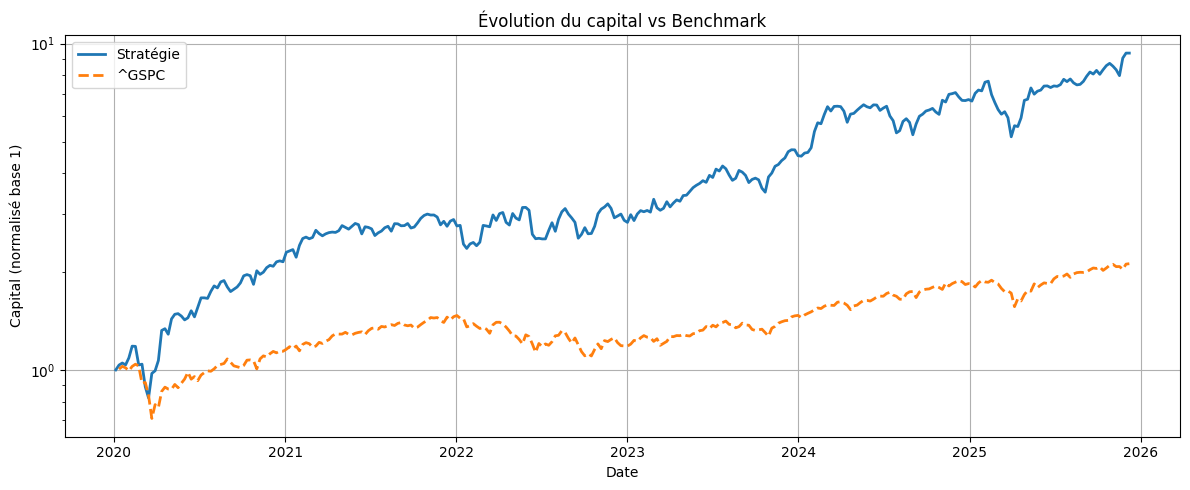

In [64]:
viz = BacktestVisualizer(results)
viz.fetch_benchmark()
viz.plot_capital_vs_benchmark()

In [65]:
results.sort_values(by=['Return'], ascending=True, inplace=True)
results.head(50)

,Capital,Return,Ticker_Count,Fees,Return_Mean
Date,,,,,
2022-06-12,27671.080216,-0.155487,19,0,-0.155487
2020-03-08,9433.485455,-0.146931,6,4,-0.146931
2025-03-30,55050.164226,-0.125725,6,1,-0.125725
2022-01-16,25817.303708,-0.123753,8,1,-0.123753
2020-02-23,11002.151908,-0.122749,8,2,-0.122749
2022-09-18,26910.908626,-0.106058,5,1,-0.106058
2025-02-16,74111.542596,-0.090690,9,0,-0.090690
2024-09-01,55851.472043,-0.083561,20,1,-0.083561
2024-07-28,56596.522466,-0.082347,18,5,-0.082347
